<a href="https://colab.research.google.com/github/newyan/LearnAI/blob/main/ai_learn_phase1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# value_counts() for counting categories
# groupby() for split-apply-combine — group the rows by species,
# then compute something per group. That groupby pattern is
# half of real-world data analysis.
import pandas as pd

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)

print(df.shape)
print(df.head())

print('=== flowers count of each species ===')
print(df['species'].value_counts())
print('=== average petal_length for each species ===')
print(df.groupby('species')['petal_length'].mean())
print('=== widest sepals on average ===')
print(df.groupby('species')['sepal_width'].mean().idxmax())
print(df.groupby('species')['sepal_width'].mean().max())

(150, 5)
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
=== flowers count of each species ===
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64
=== average petal_length for each species ===
species
setosa        1.462
versicolor    4.260
virginica     5.552
Name: petal_length, dtype: float64
=== widest sepals on average ===
setosa
3.428


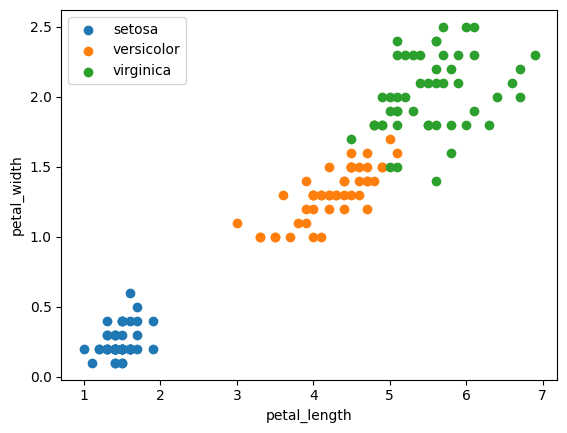

In [10]:
# 1. Scatter plot: x = petal_length, y = petal_width, one color per species
#    (hint: loop over df["species"].unique(); for each species, filter its
#     rows with a boolean mask and plt.scatter() them with label=species)
# 2. Add axis labels, a legend, and plt.show()
# 3. Look at the plot: what pattern do you see? One sentence.

import matplotlib.pyplot as plt
import pandas as pd

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)

#print(df.shape)
#print(df.head())

for species in df['species'].unique():
    df_species = df[df['species'] == species]
    plt.scatter(df_species['petal_length'], df_species['petal_width'], label=species)

plt.xlabel('petal_length')
plt.ylabel('petal_width')
plt.legend()
plt.show()

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import pandas as pd

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)

X = df[["sepal_length", "sepal_width", "petal_length", "petal_width"]]
y = df["species"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = KNeighborsClassifier(n_neighbors=15)
model.fit(X_train, y_train)
print("accuracy:", accuracy_score(y_test, model.predict(X_test)))
#print(y_test)
#print(model.predict(X_test))

accuracy: 1.0
